In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv(
    "../dataset/Customer IT Support - Ticket Dataset/dataset-tickets-multi-lang-4-20k.csv"
)



In [14]:
df.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


In [15]:
df.shape

(20000, 15)

In [16]:
df.columns.to_list()

['subject',
 'body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'tag_1',
 'tag_2',
 'tag_3',
 'tag_4',
 'tag_5',
 'tag_6',
 'tag_7',
 'tag_8']

In [ ]:
df.info()

<bound method DataFrame.info of                                                  subject  \
0      Unvorhergesehener Absturz der Datenanalyse-Pla...   
1                               Customer Support Inquiry   
2                          Data Analytics for Investment   
3                     Krankenhaus-Dienstleistung-Problem   
4                                               Security   
...                                                  ...   
19995     Assistance Needed for IFTTT Docker Integration   
19996        Bitten um Unterstützung bei der Integration   
19997                                                NaN   
19998            Hilfe bei digitalen Strategie-Problemen   
19999  Optimierung Ihrer Datenanalyse-Plattform erlei...   

                                                    body  \
0      Die Datenanalyse-Plattform brach unerwartet ab...   
1      Seeking information on digital strategies that...   
2      I am contacting you to request information on ...   
3      

In [18]:
df.isnull().sum()

subject      1461
body            2
answer          4
type            0
queue           0
priority        0
language        0
tag_1           0
tag_2          46
tag_3          95
tag_4        1539
tag_5        6909
tag_6       12649
tag_7       16072
tag_8       18093
dtype: int64

In [19]:
df['language'].value_counts()

language
en    11923
de     8077
Name: count, dtype: int64

In [20]:
df['priority'].value_counts()

priority
medium    8144
high      7801
low       4055
Name: count, dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['type'].value_counts()

type
Incident    7978
Request     5763
Problem     4184
Change      2075
Name: count, dtype: int64

In [23]:
df['queue'].value_counts()

queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64

In [24]:
df.nunique()

subject     18539
body        19998
answer      19996
type            4
queue          10
priority        3
language        2
tag_1         148
tag_2         204
tag_3         344
tag_4         481
tag_5         578
tag_6         566
tag_7         492
tag_8         386
dtype: int64

In [25]:
pd.crosstab(df['language'], df['priority'], margins=True, normalize='index')

priority,high,low,medium
language,,,
de,0.399901,0.204903,0.395196
en,0.383377,0.201292,0.415332
All,0.390050,0.202750,0.407200


In [26]:
pd.crosstab(df['type'], df['priority'], margins=True, normalize='index')

priority,high,low,medium
type,,,
Change,0.372530,0.218795,0.408675
Incident,0.441965,0.183254,0.374781
Problem,0.369025,0.206262,0.424713
Request,0.339754,0.221412,0.438834
All,0.390050,0.202750,0.407200


In [27]:
df['subject_length'] = df['subject'].fillna('').str.len()
df['body_length'] = df['body'].fillna('').str.len()

df[['subject_length', 'body_length']].describe()

,subject_length,body_length
count,20000.000000,20000.00000
mean,41.594600,394.43810
std,21.582385,248.26091
min,0.000000,0.00000
25%,31.000000,198.00000
50%,41.000000,357.00000
75%,53.000000,555.00000
max,412.000000,2259.00000


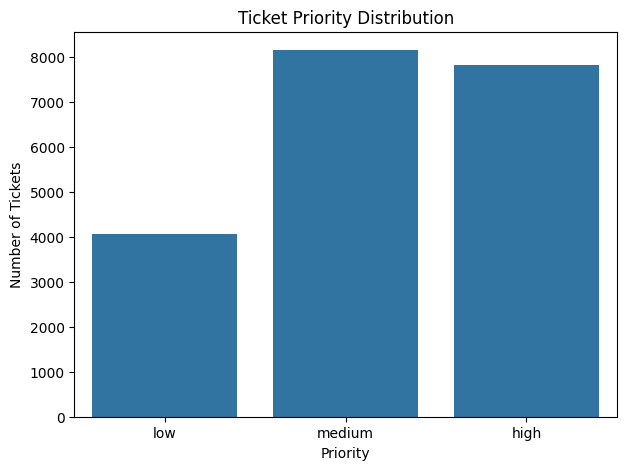

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='priority')

plt.title('Ticket Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.show()

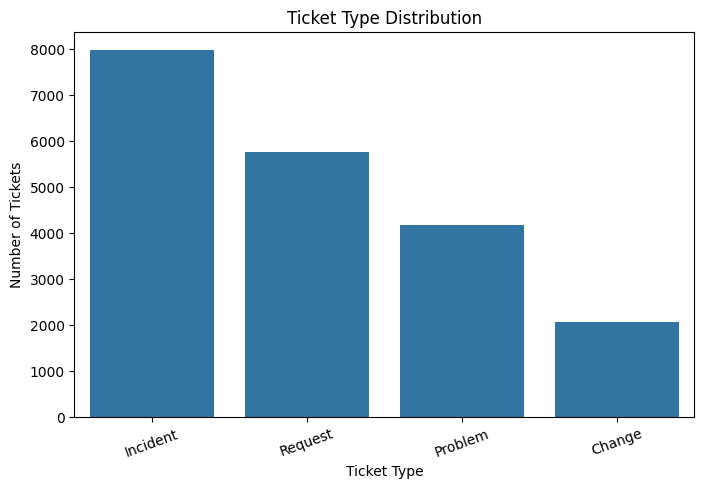

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='type', order=df['type'].value_counts().index)

plt.title('Ticket Type Distribution')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=20)
plt.show()

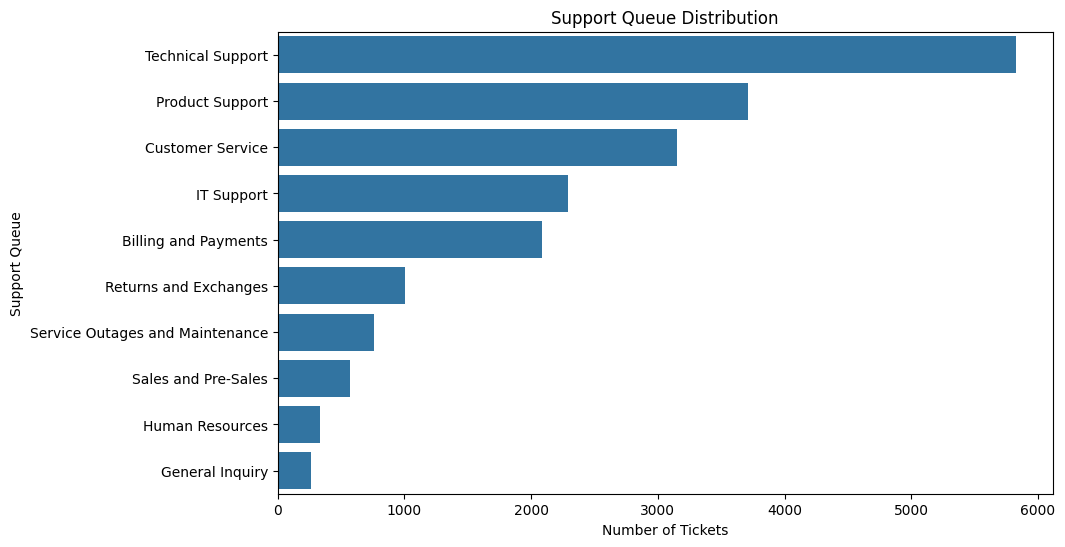

In [30]:
plt.figure(figsize=(10, 6))

queue_order = df['queue'].value_counts().index

sns.countplot(data=df, y='queue', order=queue_order)

plt.title('Support Queue Distribution')
plt.xlabel('Number of Tickets')
plt.ylabel('Support Queue')
plt.show()

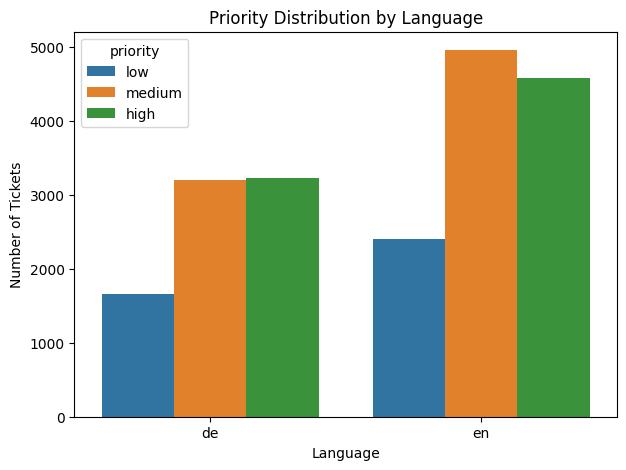

In [31]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='language', hue='priority')

plt.title('Priority Distribution by Language')
plt.xlabel('Language')
plt.ylabel('Number of Tickets')
plt.show()

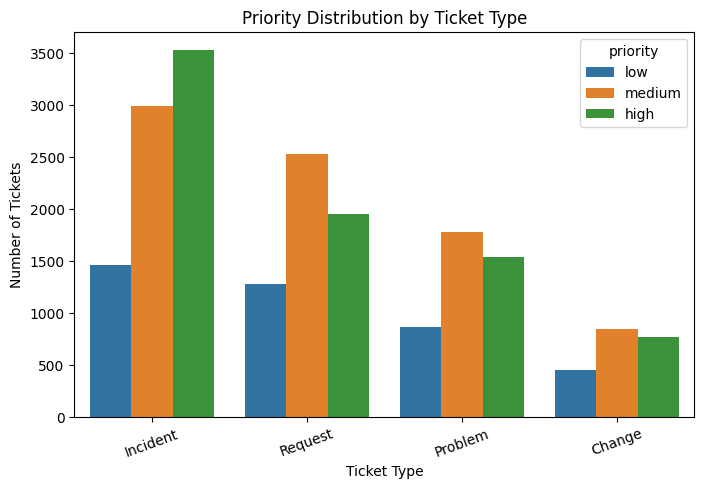

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='type', hue='priority')

plt.title('Priority Distribution by Ticket Type')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=20)
plt.show()

# 2. Data Cleaning

In this section, we clean the customer IT support ticket dataset by:
- Handling missing values
- Removing unnecessary columns
- Cleaning text data
- Standardizing categorical values
- Preparing the dataset for feature engineering and model training

In [53]:
df_clean = df.copy()

df_clean.shape

(20000, 17)

In [54]:
df_clean['subject'] = df_clean['subject'].fillna('')

In [55]:
df_clean['subject'].isnull().sum()

np.int64(0)

In [56]:
df_clean['body'] = df_clean['body'].fillna('')

In [57]:
df_clean['body'].isnull().sum()

np.int64(0)

In [58]:
df_clean['answer'] = df_clean['answer'].fillna('')

In [59]:
df_clean['answer'].isnull().sum()

np.int64(0)

#Handle Tag columns

In [60]:
tag_columns = [
    'tag_1', 'tag_2', 'tag_3', 'tag_4',
    'tag_5', 'tag_6', 'tag_7', 'tag_8'
]

df_clean[tag_columns] = df_clean[tag_columns].fillna('none')

In [61]:
df_clean.isnull().sum()

subject           0
body              0
answer            0
type              0
queue             0
priority          0
language          0
tag_1             0
tag_2             0
tag_3             0
tag_4             0
tag_5             0
tag_6             0
tag_7             0
tag_8             0
subject_length    0
body_length       0
dtype: int64

In [62]:
text_columns = ['subject', 'body', 'answer']

for col in text_columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

In [63]:
empty_tickets = (
    (df_clean['subject'] == '') &
    (df_clean['body'] == '')
)

empty_tickets.sum()

np.int64(0)

In [64]:
df_clean = df_clean[~empty_tickets].copy()

In [65]:
df_clean.shape

(20000, 17)

Clean Categorical Columns

In [66]:
categorical_columns = [
    'type',
    'queue',
    'priority',
    'language'
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [67]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


type:
type
Incident    7978
Request     5763
Problem     4184
Change      2075
Name: count, dtype: int64

queue:
queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64

priority:
priority
medium    8144
high      7801
low       4055
Name: count, dtype: int64

language:
language
en    11923
de     8077
Name: count, dtype: int64


In [71]:
df_clean.to_csv(
    '../dataset/processed/cleaned_tickets.csv',
    index=False
)

In [73]:
import os

os.path.exists('../dataset/processed/cleaned_tickets.csv')

True

In [74]:
df_clean.shape

(20000, 17)

In [75]:
df_clean.isnull().sum()

subject           0
body              0
answer            0
type              0
queue             0
priority          0
language          0
tag_1             0
tag_2             0
tag_3             0
tag_4             0
tag_5             0
tag_6             0
tag_7             0
tag_8             0
subject_length    0
body_length       0
dtype: int64

# Feature Engineering

In [78]:
# Create a copy so the cleaned dataframe remains safe
df_fe = df_clean.copy()

# Total text length
df_fe['total_text_length'] = (
    df_fe['subject_length'] + df_fe['body_length']
)

# Number of words in subject
df_fe['subject_word_count'] = (
    df_fe['subject'].fillna('').str.split().str.len()
)

# Number of words in body
df_fe['body_word_count'] = (
    df_fe['body'].fillna('').str.split().str.len()
)

# Number of tags available for each ticket
tag_columns = [f'tag_{i}' for i in range(1, 9)]

df_fe['tag_count'] = (
    df_fe[tag_columns]
    .notna()
    .sum(axis=1)
)

df_fe[['subject_length',
       'body_length',
       'total_text_length',
       'subject_word_count',
       'body_word_count',
       'tag_count']].head()

,subject_length,body_length,total_text_length,subject_word_count,body_word_count,tag_count
0,52,252,304,4,38,8
1,24,225,249,3,38,8
2,29,696,725,4,105,8
3,34,221,255,1,27,8
4,8,675,683,1,113,8


In [79]:
df_fe[
    [
        'subject_length',
        'body_length',
        'total_text_length',
        'subject_word_count',
        'body_word_count',
        'tag_count'
    ]
].describe()

,subject_length,body_length,total_text_length,subject_word_count,body_word_count,tag_count
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.0
mean,41.594600,394.43810,436.032700,5.127050,57.036250,8.0
std,21.582385,248.26091,250.291682,2.753377,36.599323,0.0
min,0.000000,0.00000,4.000000,0.000000,0.000000,8.0
25%,31.000000,198.00000,240.000000,4.000000,28.000000,8.0
50%,41.000000,357.00000,400.000000,5.000000,51.000000,8.0
75%,53.000000,555.00000,594.000000,7.000000,82.000000,8.0
max,412.000000,2259.00000,2283.000000,45.000000,281.000000,8.0


In [80]:
df_fe[
    [
        'subject_length',
        'body_length',
        'total_text_length',
        'subject_word_count',
        'body_word_count',
        'tag_count'
    ]
].corr()

,subject_length,body_length,total_text_length,subject_word_count,body_word_count,tag_count
subject_length,1.000000,0.051012,0.136827,0.918275,0.039871,NaN
body_length,0.051012,1.000000,0.996285,0.019948,0.981485,NaN
total_text_length,0.136827,0.996285,1.000000,0.098968,0.976960,NaN
subject_word_count,0.918275,0.019948,0.098968,1.000000,0.043352,NaN
body_word_count,0.039871,0.981485,0.976960,0.043352,1.000000,NaN
tag_count,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
df_fe['text'] = (
    df_fe['subject'].fillna('') + ' ' +
    df_fe['body'].fillna('')
)

In [82]:
df_fe[['subject', 'body', 'text']].head()

,subject,body,text
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Unvorhergesehener Absturz der Datenanalyse-Pla...
1,Customer Support Inquiry,Seeking information on digital strategies that...,Customer Support Inquiry Seeking information o...
2,Data Analytics for Investment,I am contacting you to request information on ...,Data Analytics for Investment I am contacting ...
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Krankenhaus-Dienstleistung-Problem Ein Medien-...
4,Security,"Dear Customer Support, I am reaching out to in...","Security Dear Customer Support, I am reaching ..."


In [83]:
categorical_columns = [
    'type',
    'queue',
    'language'
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df_fe[col].value_counts())


type
type
Incident    7978
Request     5763
Problem     4184
Change      2075
Name: count, dtype: int64

queue
queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64

language
language
en    11923
de     8077
Name: count, dtype: int64


In [84]:
print(df_fe['priority'].value_counts())

priority
medium    8144
high      7801
low       4055
Name: count, dtype: int64


In [86]:
df_fe.shape


(20000, 22)

In [87]:

df_fe.dtypes


subject                 str
body                    str
answer                  str
type                    str
queue                   str
priority                str
language                str
tag_1                   str
tag_2                   str
tag_3                   str
tag_4                   str
tag_5                   str
tag_6                   str
tag_7                   str
tag_8                   str
subject_length        int64
body_length           int64
total_text_length     int64
subject_word_count    int64
body_word_count       int64
tag_count             int64
text                    str
dtype: object

In [89]:

df_fe.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,...,tag_6,tag_7,tag_8,subject_length,body_length,total_text_length,subject_word_count,body_word_count,tag_count,text
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,...,Outage,Documentation,none,52,252,304,4,38,8,Unvorhergesehener Absturz der Datenanalyse-Pla...
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,...,none,none,none,24,225,249,3,38,8,Customer Support Inquiry Seeking information o...
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,...,Feature,none,none,29,696,725,4,105,8,Data Analytics for Investment I am contacting ...
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,...,Resolution,Feedback,none,34,221,255,1,27,8,Krankenhaus-Dienstleistung-Problem Ein Medien-...
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,...,Guidance,none,none,8,675,683,1,113,8,"Security Dear Customer Support, I am reaching ..."


In [90]:
df_fe.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8',
       'subject_length', 'body_length', 'total_text_length',
       'subject_word_count', 'body_word_count', 'tag_count', 'text'],
      dtype='str')